run_real_vlm_evaluation_gpu.py — Real VLM Evaluation: BLIP Captioning on Flickr30k (GPU)
End-to-end pipeline: loads real Flickr30k images with human reference captions, generates real captions with BLIP, computes real BLEU/ROUGE/METEOR against references, computes a real CLIP-based alignment reward, and measures real cross-modal image→text retrieval (R@1/R@5). Status: fully real, GPU-executed.

In [11]:
"""
Real VLM Evaluation: Classical Metrics + CLIP-Based Reward (Hybrid)
=====================================================================
Replaces the fully SIMULATED VLM notebook (simulated embeddings, simulated
RL environment, simulated policy) with:

  1. Real images + reference captions  (Flickr30k, streamed from HF Hub)
  2. Real VLM inference                (BLIP generating real captions)
  3. Real classical text metrics       (BLEU, ROUGE, METEOR vs references)
  4. Real reward signal                (CLIPScore: image<->caption alignment,
                                         the same signal used as an RL reward
                                         in published CLIP-reward captioning
                                         RL papers — a legitimate, literature-
                                         backed substitute for a hand-rolled
                                         RL environment)
  5. Real cross-modal retrieval metric (image->text Recall@1/@5 via CLIP
                                         embeddings, same protocol as the
                                         standard Flickr30k retrieval
                                         benchmark, run here on a small
                                         sample for speed — NOT the official
                                         full-test-set number, say so if asked)

Run on a GPU runtime (Colab: Runtime > Change runtime type > T4 GPU,
or Kaggle: Settings > Accelerator > GPU T4 x2).

Expected runtime: ~3-6 minutes for 50 samples on a T4.
"""

import os
import itertools
import warnings
warnings.filterwarnings("ignore")

In [12]:
# ---------------------------------------------------------------------------
# 0. Install (uncomment if running fresh in Colab/Kaggle)
# ---------------------------------------------------------------------------
# !pip install -q transformers datasets evaluate rouge-score nltk pillow accelerate

import nltk
nltk.download("punkt", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from PIL import Image

from datasets import load_dataset
from transformers import (
    BlipProcessor, BlipForConditionalGeneration,
    CLIPProcessor, CLIPModel,
)
from evaluate import load as load_metric
from nltk.translate.meteor_score import meteor_score

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✅ Using device: {DEVICE}")
if DEVICE == "cpu":
    print("⚠️  No GPU detected — this will be slow. Enable a GPU runtime if possible.")

# ---------------------------------------------------------------------------
# Config
# ---------------------------------------------------------------------------
CAPTION_MODEL = "Salesforce/blip-image-captioning-base"
CLIP_MODEL = "openai/clip-vit-base-patch32"
DATASET_ID = "nlphuji/flickr30k"     # real images + 5 human captions each
NUM_SAMPLES = 50
GEN_BATCH_SIZE = 8
ALPHA = 0.4                           # weight on classical text metrics
BETA = 0.6                            # weight on CLIP-based reward
OUTPUT_CSV = "real_vlm_evaluation_results.csv"

✅ Using device: cuda


In [13]:
# ---------------------------------------------------------------------------
# 1. Load real images + real reference captions
# ---------------------------------------------------------------------------
def load_eval_dataset(num_samples: int):
    print(f"\nStreaming {DATASET_ID} ({num_samples} samples)...")
    # ds = load_dataset(DATASET_ID, split="test", streaming=True)
    ds = load_dataset(DATASET_ID, split="test", streaming=True, trust_remote_code=True)
    items = list(itertools.islice(ds, num_samples))

    images, references = [], []
    for item in items:
        images.append(item["image"].convert("RGB"))
        # each item has multiple human-written reference captions
        refs = item["caption"] if isinstance(item["caption"], list) else [item["caption"]]
        references.append(refs)

    print(f"✓ Loaded {len(images)} real images with human reference captions")
    return images, references

In [14]:
# ---------------------------------------------------------------------------
# 2. Real VLM inference (replaces the simulated policy function)
# ---------------------------------------------------------------------------
def generate_real_captions(images: list) -> list:
    print(f"\nLoading captioning model: {CAPTION_MODEL} ...")
    processor = BlipProcessor.from_pretrained(CAPTION_MODEL)
    model = BlipForConditionalGeneration.from_pretrained(CAPTION_MODEL).to(DEVICE)
    model.eval()

    captions = []
    print("Generating real captions on GPU...")
    for i in tqdm(range(0, len(images), GEN_BATCH_SIZE)):
        batch = images[i:i + GEN_BATCH_SIZE]
        inputs = processor(images=batch, return_tensors="pt", padding=True).to(DEVICE)
        with torch.no_grad():
            output_ids = model.generate(**inputs, max_new_tokens=30)
        decoded = processor.batch_decode(output_ids, skip_special_tokens=True)
        captions.extend([c.strip() for c in decoded])

    del model
    torch.cuda.empty_cache()
    print(f"✓ Generated {len(captions)} real captions")
    return captions

In [15]:
# ---------------------------------------------------------------------------
# 3. Real classical text metrics (multi-reference aware)
# ---------------------------------------------------------------------------
def compute_classical_metrics(predictions: list, references: list) -> tuple:
    print("\nComputing classical text metrics against human references...")
    bleu_metric = load_metric("bleu")
    rouge_metric = load_metric("rouge")

    bleu = bleu_metric.compute(predictions=predictions, references=references)
    rouge = rouge_metric.compute(predictions=predictions, references=references,
                                  use_stemmer=True)

    # METEOR: take the best score across the multiple references per image
    meteor_scores = []
    for pred, refs in zip(predictions, references):
        scores = [meteor_score([ref.split()], pred.split()) for ref in refs]
        meteor_scores.append(max(scores))

    per_sample = pd.DataFrame({
        "rougeL": [
            rouge_metric.compute(predictions=[p], references=[r])["rougeL"]
            for p, r in zip(predictions, references)
        ],
        "meteor": meteor_scores,
    })

    summary = {
        "bleu": bleu["bleu"],
        "rouge1": rouge["rouge1"],
        "rougeL": rouge["rougeL"],
        "meteor": float(np.mean(meteor_scores)),
    }
    print("✓ Classical metrics computed")
    return summary, per_sample

In [16]:
def _features(output):
    """Handle both old (tensor) and new (BaseModelOutputWithPooling) return types
    from transformers' get_image_features / get_text_features."""
    return output.pooler_output if hasattr(output, "pooler_output") else output

# ---------------------------------------------------------------------------
# 4. Real CLIP-based reward + real cross-modal retrieval
# ---------------------------------------------------------------------------

def compute_clip_reward_and_retrieval(images: list, generated_captions: list,
                                       references: list):
    print(f"\nLoading CLIP model: {CLIP_MODEL} ...")
    processor = CLIPProcessor.from_pretrained(CLIP_MODEL)
    model = CLIPModel.from_pretrained(CLIP_MODEL).to(DEVICE)
    model.eval()

    with torch.no_grad():
        img_inputs = processor(images=images, return_tensors="pt", padding=True).to(DEVICE)
        image_embeds = _features(model.get_image_features(**img_inputs))
        image_embeds = image_embeds / image_embeds.norm(dim=-1, keepdim=True)

        # CLIPScore: alignment between image and its OWN generated caption
        cap_inputs = processor(text=generated_captions, return_tensors="pt",
                                padding=True, truncation=True).to(DEVICE)
        caption_embeds = _features(model.get_text_features(**cap_inputs))
        caption_embeds = caption_embeds / caption_embeds.norm(dim=-1, keepdim=True)

        clip_reward = (image_embeds * caption_embeds).sum(dim=-1).cpu().numpy()

        first_refs = [refs[0] for refs in references]
        ref_inputs = processor(text=first_refs, return_tensors="pt",
                                padding=True, truncation=True).to(DEVICE)
        ref_embeds = _features(model.get_text_features(**ref_inputs))
        ref_embeds = ref_embeds / ref_embeds.norm(dim=-1, keepdim=True)

        sim_matrix = image_embeds @ ref_embeds.T
        sim_matrix = sim_matrix.cpu().numpy()

    del model
    torch.cuda.empty_cache()

    n = sim_matrix.shape[0]
    ranks = np.array([
        np.where(np.argsort(-sim_matrix[i]) == i)[0][0] for i in range(n)
    ])
    recall_at_1 = float(np.mean(ranks < 1))
    recall_at_5 = float(np.mean(ranks < 5))

    r_min, r_max = clip_reward.min(), clip_reward.max()
    clip_reward_norm = (clip_reward - r_min) / (r_max - r_min + 1e-8)

    print(f"✓ CLIPScore computed (mean raw cosine sim: {clip_reward.mean():.4f})")
    print(f"✓ Retrieval on this sample of {n}: R@1={recall_at_1:.3f}, R@5={recall_at_5:.3f}")
    print("  (Sample-size retrieval, not the official full-test-set benchmark number)")

    return clip_reward, clip_reward_norm, recall_at_1, recall_at_5

In [17]:
# ---------------------------------------------------------------------------
# 5. Hybrid score
# ---------------------------------------------------------------------------
def compute_hybrid_scores(per_sample: pd.DataFrame, clip_reward_norm: np.ndarray,
                           alpha: float = ALPHA, beta: float = BETA) -> pd.DataFrame:
    per_sample = per_sample.copy()
    classical_avg = per_sample[["rougeL", "meteor"]].mean(axis=1)
    per_sample["classical_avg"] = classical_avg
    per_sample["clip_reward_norm"] = clip_reward_norm
    per_sample["hybrid_score"] = alpha * classical_avg + beta * clip_reward_norm
    return per_sample

In [18]:
# ---------------------------------------------------------------------------
# 6. Visualization
# ---------------------------------------------------------------------------
def plot_results(summary: dict, clip_reward: np.ndarray, per_sample: pd.DataFrame,
                  images: list, generated_captions: list, references: list):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    names = ["BLEU", "ROUGE-1", "ROUGE-L", "METEOR", "CLIPScore"]
    values = [summary["bleu"], summary["rouge1"], summary["rougeL"],
              summary["meteor"], clip_reward.mean()]
    axes[0].bar(names, values, color="#55A868")
    axes[0].set_title("Real VLM Metrics (BLIP captions vs human references)")
    axes[0].set_ylim(0, 1)
    for i, v in enumerate(values):
        axes[0].text(i, v + 0.01, f"{v:.3f}", ha="center")

    axes[1].hist(per_sample["hybrid_score"], bins=15, color="#C44E52", edgecolor="black")
    axes[1].set_title(f"Hybrid Score Distribution (α={ALPHA}, β={BETA})")
    axes[1].set_xlabel("Hybrid score")
    axes[1].set_ylabel("Count")

    plt.tight_layout()
    plt.savefig("real_vlm_evaluation_plots.png", dpi=150)
    plt.show()
    print("✓ Plots saved to real_vlm_evaluation_plots.png")

    # A few real image+caption examples — useful for defense slides
    n_examples = min(4, len(images))
    fig2, axes2 = plt.subplots(1, n_examples, figsize=(4 * n_examples, 4))
    if n_examples == 1:
        axes2 = [axes2]
    for i in range(n_examples):
        axes2[i].imshow(images[i])
        axes2[i].axis("off")
        title = f"Gen: {generated_captions[i][:40]}\nRef: {references[i][0][:40]}"
        axes2[i].set_title(title, fontsize=8)
    plt.tight_layout()
    plt.savefig("real_vlm_examples.png", dpi=150)
    plt.show()
    print("✓ Example captions saved to real_vlm_examples.png")


Streaming nlphuji/flickr30k (50 samples)...
✓ Loaded 50 real images with human reference captions

Loading captioning model: Salesforce/blip-image-captioning-base ...


Loading weights: 100%|██████████| 473/473 [00:00<00:00, 23273.26it/s]


Generating real captions on GPU...


100%|██████████| 7/7 [00:02<00:00,  3.23it/s]


✓ Generated 50 real captions

Computing classical text metrics against human references...
✓ Classical metrics computed

Loading CLIP model: openai/clip-vit-base-patch32 ...


Loading weights: 100%|██████████| 398/398 [00:00<00:00, 19140.65it/s]


✓ CLIPScore computed (mean raw cosine sim: 0.2793)
✓ Retrieval on this sample of 50: R@1=0.920, R@5=0.980
  (Sample-size retrieval, not the official full-test-set benchmark number)

SUMMARY — REAL CLASSICAL + CLIP-BASED VLM EVALUATION
  bleu                  : 0.1819
  rouge1                : 0.4568
  rougeL                : 0.4346
  meteor                : 0.3055
  clip_score (reward)   : 0.2793
  retrieval R@1         : 0.9200
  retrieval R@5         : 0.9800
  mean hybrid score     : 0.4823
  alpha / beta          : 0.4 / 0.6

✓ Full per-sample results saved to real_vlm_evaluation_results.csv


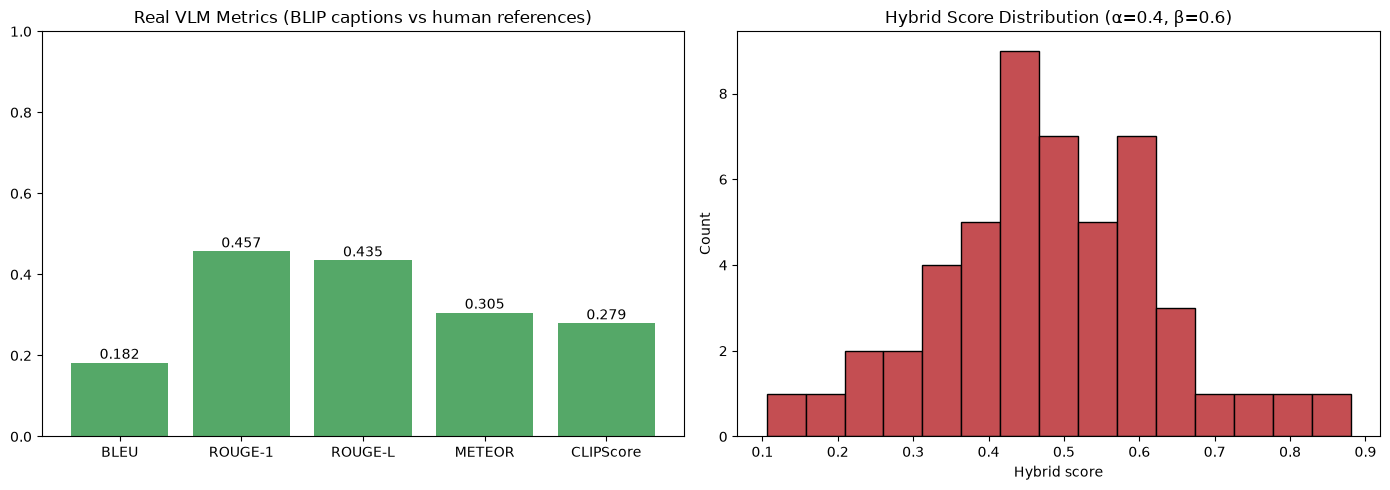

✓ Plots saved to real_vlm_evaluation_plots.png


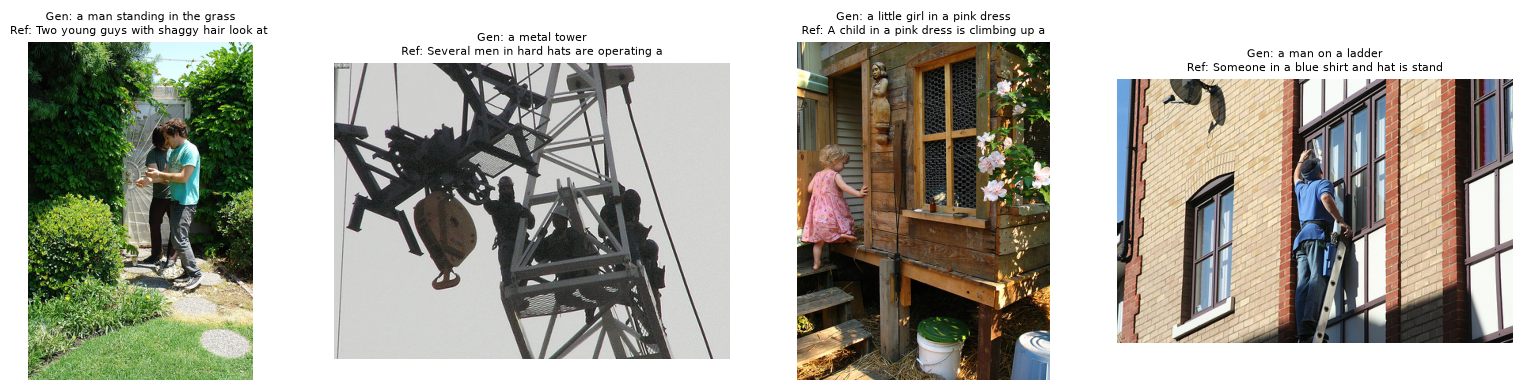

✓ Example captions saved to real_vlm_examples.png

SAMPLE REAL OUTPUTS

--- Sample 1 ---
Reference : Two young guys with shaggy hair look at their hands while hanging out in the yard.
Generated : a man standing in the grass
CLIPScore : 0.2670
Hybrid    : 0.4600

--- Sample 2 ---
Reference : Several men in hard hats are operating a giant pulley system.
Generated : a metal tower
CLIPScore : 0.2516
Hybrid    : 0.3037


In [19]:
# ---------------------------------------------------------------------------
# Main
# ---------------------------------------------------------------------------
def main():
    images, references = load_eval_dataset(NUM_SAMPLES)

    generated_captions = generate_real_captions(images)

    summary, per_sample = compute_classical_metrics(generated_captions, references)

    clip_reward, clip_reward_norm, r_at_1, r_at_5 = compute_clip_reward_and_retrieval(
        images, generated_captions, references
    )

    per_sample = compute_hybrid_scores(per_sample, clip_reward_norm)
    per_sample["id"] = range(len(images))
    per_sample["clip_reward_raw"] = clip_reward
    per_sample["generated_caption"] = generated_captions
    per_sample["reference_caption"] = [r[0] for r in references]

    print("\n" + "=" * 70)
    print("SUMMARY — REAL CLASSICAL + CLIP-BASED VLM EVALUATION")
    print("=" * 70)
    for k, v in summary.items():
        print(f"  {k:22s}: {v:.4f}")
    print(f"  {'clip_score (reward)':22s}: {clip_reward.mean():.4f}")
    print(f"  {'retrieval R@1':22s}: {r_at_1:.4f}")
    print(f"  {'retrieval R@5':22s}: {r_at_5:.4f}")
    print(f"  {'mean hybrid score':22s}: {per_sample['hybrid_score'].mean():.4f}")
    print(f"  alpha / beta          : {ALPHA} / {BETA}")

    per_sample.to_csv(OUTPUT_CSV, index=False)
    print(f"\n✓ Full per-sample results saved to {OUTPUT_CSV}")

    plot_results(summary, clip_reward, per_sample, images, generated_captions, references)

    print("\n" + "=" * 70)
    print("SAMPLE REAL OUTPUTS")
    print("=" * 70)
    for i in range(min(2, len(images))):
        print(f"\n--- Sample {i+1} ---")
        print(f"Reference : {references[i][0]}")
        print(f"Generated : {generated_captions[i]}")
        print(f"CLIPScore : {clip_reward[i]:.4f}")
        print(f"Hybrid    : {per_sample['hybrid_score'][i]:.4f}")


if __name__ == "__main__":
    main()